# Task 03 - Collaborative Filtering For Recommendation

This notebook is self-contained and portable across local Jupyter environments and Google Colab.

## Rubric Mapping

- Read `ratings2k.csv`: Spark loading section
- Represent each user profile as a rating vector with `0` meaning missing: user-profile construction
- Use a similarity metric that does not treat `0` as negative: `CenteredCosineSimilarity`
- Implement collaborative filtering for rating prediction: `UserBasedCF`
- Propose a quick approach without enumerating the whole dataset: `OverlapHashIndex`
- Integrate the fast approach into the recommendation pipeline: experiment runner
- OOP and compact code: focused classes
- Conduct experiments for several `N` values: `CFExperimentRunner`
- Draw RMSE bar chart: RMSE section
- Compare runtime with versus without the fast neighbor lookup: runtime comparison section


## 1. Dependency Setup


In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "pyspark": "pyspark",
}

def ensure_packages(required_packages):
    missing = []
    for package_name, module_name in required_packages.items():
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(package_name)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure_packages(REQUIRED_PACKAGES)


## 2. Imports, Paths, And Configuration


In [2]:
import math
import sys
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

plt.style.use("seaborn-v0_8-whitegrid")

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path.cwd()
DATA_PATH = OUTPUT_DIR / "ratings2k.csv"
RESULTS_PATH = OUTPUT_DIR / "task03_results.csv"
RMSE_CHART_PATH = OUTPUT_DIR / "task03_rmse_by_n.png"
RUNTIME_CHART_PATH = OUTPUT_DIR / "task03_runtime_compare.png"

@dataclass
class Task03Config:
    train_ratio: float = 0.8
    test_ratio: float = 0.2
    candidate_pool_size: int = 25
    n_values: tuple = (5, 10, 15, 20, 25)
    timing_repetitions: int = 100
    seed: int = 42

CONFIG = Task03Config()
print(CONFIG)


Task03Config(train_ratio=0.8, test_ratio=0.2, candidate_pool_size=25, n_values=(5, 10, 15, 20, 25), timing_repetitions=100, seed=42)


## 3. Data File Discovery And Spark Session


In [3]:
def upload_file_in_colab(file_name: str) -> Path:
    from google.colab import files

    print(f"`{file_name}` was not found. Please upload it to the Colab runtime now.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(
            f"Expected `{file_name}` in the uploaded files, but received: {list(uploaded)}"
        )
    uploaded_path = Path("/content") / file_name
    print("Uploaded to:", uploaded_path)
    return uploaded_path.resolve()

def find_data_file(file_name: str) -> Path:
    candidate_paths = [
        Path.cwd() / file_name,
        Path.cwd().parent / file_name,
        Path.cwd().parent.parent / file_name,
        Path("/content") / file_name,
    ]
    for candidate_path in candidate_paths:
        if candidate_path.exists():
            return candidate_path.resolve()
    if IN_COLAB:
        return upload_file_in_colab(file_name)
    raise FileNotFoundError(f"Cannot find {file_name}. Please upload or copy it next to this notebook.")

DATA_PATH = find_data_file("ratings2k.csv")
print("Using data file:", DATA_PATH)

def build_spark(app_name: str) -> SparkSession:
    spark_session = (
        SparkSession.builder.master("local[*]")
        .appName(app_name)
        .config("spark.sql.shuffle.partitions", "16")
        .getOrCreate()
    )
    spark_session.sparkContext.setLogLevel("ERROR")
    return spark_session

spark = build_spark("MMDS-Task03")


Using data file: D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task03\ratings2k.csv


## 4. Dataset Builder And Similarity Metric


In [4]:
class RatingsDatasetBuilder:
    def __init__(self, spark_session, config, data_path):
        self.spark = spark_session
        self.config = config
        self.data_path = data_path

    def load(self):
        return (
            self.spark.read.csv(str(self.data_path), header=True, inferSchema=True)
            .select(
                F.col("user").cast("int"),
                F.col("item").cast("int"),
                F.col("rating").cast("double"),
            )
        )

    def split(self):
        ratings_df = self.load().cache()
        train_df, test_df = ratings_df.randomSplit(
            [self.config.train_ratio, self.config.test_ratio],
            seed=self.config.seed,
        )
        return ratings_df, train_df.cache(), test_df.cache()


class CenteredCosineSimilarity:
    @staticmethod
    def compute(user_ratings, other_ratings):
        common_items = set(user_ratings) & set(other_ratings)
        if len(common_items) < 2:
            return 0.0
        user_mean = sum(user_ratings[item_id] for item_id in common_items) / len(common_items)
        other_mean = sum(other_ratings[item_id] for item_id in common_items) / len(common_items)
        user_centered = [user_ratings[item_id] - user_mean for item_id in common_items]
        other_centered = [other_ratings[item_id] - other_mean for item_id in common_items]
        numerator = sum(left * right for left, right in zip(user_centered, other_centered))
        denominator = math.sqrt(sum(value * value for value in user_centered)) * math.sqrt(
            sum(value * value for value in other_centered)
        )
        return numerator / denominator if denominator else 0.0


## 5. Fast Candidate Index


In [5]:
class OverlapHashIndex:
    def __init__(self, candidate_pool_size):
        self.candidate_pool_size = candidate_pool_size
        self.user_to_candidates = {}

    def fit(self, user_to_ratings, item_to_users):
        for user_id, ratings_map in user_to_ratings.items():
            overlap_counter = Counter()
            for item_id in ratings_map:
                for other_user_id in item_to_users[item_id]:
                    if other_user_id != user_id:
                        overlap_counter[other_user_id] += 1
            self.user_to_candidates[user_id] = [
                other_user_id
                for other_user_id, _ in overlap_counter.most_common(self.candidate_pool_size)
            ]
        return self

    def get_candidates(self, user_id):
        return self.user_to_candidates.get(user_id, [])


## 6. User-Based CF Model


In [6]:
class UserBasedCF:
    def __init__(self, user_to_ratings, candidate_index=None):
        self.user_to_ratings = user_to_ratings
        self.candidate_index = candidate_index
        self.all_users = sorted(user_to_ratings)
        self.user_means = {
            user_id: sum(ratings_map.values()) / len(ratings_map)
            for user_id, ratings_map in user_to_ratings.items()
        }

    def _candidate_users(self, user_id, use_fast_index):
        if use_fast_index and self.candidate_index is not None:
            return self.candidate_index.get_candidates(user_id)
        return [other_user_id for other_user_id in self.all_users if other_user_id != user_id]

    def predict(self, user_id, item_id, n_neighbors, use_fast_index):
        if user_id not in self.user_to_ratings:
            return None

        scored_neighbors = []
        for other_user_id in self._candidate_users(user_id, use_fast_index):
            other_ratings = self.user_to_ratings[other_user_id]
            if item_id not in other_ratings:
                continue
            similarity = CenteredCosineSimilarity.compute(
                self.user_to_ratings[user_id],
                other_ratings,
            )
            if similarity > 0:
                scored_neighbors.append((similarity, other_user_id))

        scored_neighbors.sort(reverse=True)
        top_neighbors = scored_neighbors[:n_neighbors]
        if not top_neighbors:
            return self.user_means[user_id]

        numerator = 0.0
        denominator = 0.0
        for similarity, other_user_id in top_neighbors:
            numerator += similarity * (
                self.user_to_ratings[other_user_id][item_id] - self.user_means[other_user_id]
            )
            denominator += abs(similarity)
        return self.user_means[user_id] + (numerator / denominator if denominator else 0.0)


## 7. Collaborative Filtering Experiment Runner


In [7]:
class CFExperimentRunner:
    def __init__(self, config, model):
        self.config = config
        self.model = model

    def rmse(self, predictions, labels):
        return math.sqrt(sum((prediction - label) ** 2 for prediction, label in zip(predictions, labels)) / len(labels))

    def evaluate(self, test_rows, n_neighbors, use_fast_index):
        predictions = []
        labels = []
        for row in test_rows:
            prediction = self.model.predict(
                user_id=int(row["user"]),
                item_id=int(row["item"]),
                n_neighbors=n_neighbors,
                use_fast_index=use_fast_index,
            )
            if prediction is not None:
                predictions.append(prediction)
                labels.append(float(row["rating"]))
        return self.rmse(predictions, labels), predictions, labels

    def compare_runtime(self, test_rows, n_neighbors):
        timings = {}
        for use_fast_index, label in [(False, "baseline"), (True, "indexed")]:
            start = time.perf_counter()
            for _ in range(self.config.timing_repetitions):
                for row in test_rows:
                    self.model.predict(
                        user_id=int(row["user"]),
                        item_id=int(row["item"]),
                        n_neighbors=n_neighbors,
                        use_fast_index=use_fast_index,
                    )
            timings[label] = time.perf_counter() - start
        return timings


## 8. Load Data And Split Train/Test Sets


In [8]:
dataset_builder = RatingsDatasetBuilder(spark, CONFIG, DATA_PATH)
ratings_df, train_df, test_df = dataset_builder.split()

print("Ratings rows:", ratings_df.count())
print("Train rows:", train_df.count())
print("Test rows:", test_df.count())


Ratings rows: 2365


Train rows: 1949


Test rows: 416


## 9. Build Sparse User Profiles


In [9]:
train_rows = train_df.collect()
test_rows = test_df.collect()

user_to_ratings = defaultdict(dict)
item_to_users = defaultdict(set)
all_items = set()
for row in train_rows:
    user_id = int(row["user"])
    item_id = int(row["item"])
    rating = float(row["rating"])
    user_to_ratings[user_id][item_id] = rating
    item_to_users[item_id].add(user_id)
    all_items.add(item_id)

valid_test_rows = [row for row in test_rows if int(row["user"]) in user_to_ratings]
print("Valid test rows used for evaluation:", len(valid_test_rows))


Valid test rows used for evaluation: 416


## 10. Preview User Profile Matrix


In [10]:
profile_matrix = pd.DataFrame.from_dict(user_to_ratings, orient="index").fillna(0.0).sort_index()
print("User profile matrix shape:", profile_matrix.shape)
display(profile_matrix.head())


User profile matrix shape: (74, 440)


,163,167,352,422,0,67,82,131,144,145,...,451,453,454,460,464,466,51,56,343,408
1,5.0,3.5,5.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,3.5,5.0,4.5,4.0,5.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 11. Build Fast Candidate Index


In [11]:
candidate_index = OverlapHashIndex(CONFIG.candidate_pool_size).fit(user_to_ratings, item_to_users)
candidate_sizes = pd.Series([len(candidate_index.get_candidates(user_id)) for user_id in sorted(user_to_ratings)])
print("Candidate shortlist size summary:")
display(candidate_sizes.describe())

recommender = UserBasedCF(user_to_ratings=user_to_ratings, candidate_index=candidate_index)


Candidate shortlist size summary:


count    74.000000
mean     24.405405
std       3.042705
min       1.000000
25%      25.000000
50%      25.000000
75%      25.000000
max      25.000000
dtype: float64

## 12. Run RMSE And Runtime Experiments


In [12]:
experiment_runner = CFExperimentRunner(CONFIG, recommender)

results_rows = []
for n_value in CONFIG.n_values:
    rmse_value, _, _ = experiment_runner.evaluate(valid_test_rows, n_neighbors=n_value, use_fast_index=True)
    results_rows.append({"N": n_value, "rmse": rmse_value})
results_df = pd.DataFrame(results_rows)

best_n = int(results_df.sort_values("rmse").iloc[0]["N"])
runtime_result = experiment_runner.compare_runtime(valid_test_rows, n_neighbors=best_n)
results_df["baseline_runtime_seconds"] = runtime_result["baseline"]
results_df["indexed_runtime_seconds"] = runtime_result["indexed"]
results_df.to_csv(RESULTS_PATH, index=False)
print("Saved results to", RESULTS_PATH)
display(results_df)


Saved results to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task03\task03_results.csv


,N,rmse,baseline_runtime_seconds,indexed_runtime_seconds
0,5,0.959563,3.814951,2.831518
1,10,0.953223,3.814951,2.831518
2,15,0.953562,3.814951,2.831518
3,20,0.953567,3.814951,2.831518
4,25,0.953567,3.814951,2.831518


## 13. Plot RMSE By Neighbor Count


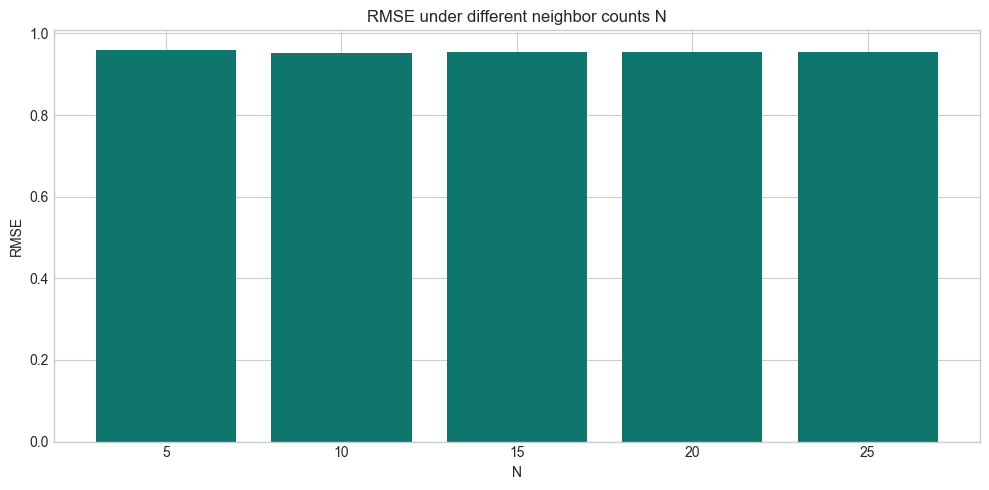

Saved RMSE chart to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task03\task03_rmse_by_n.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results_df["N"].astype(str), results_df["rmse"], color="#0f766e")
ax.set_title("RMSE under different neighbor counts N")
ax.set_xlabel("N")
ax.set_ylabel("RMSE")
fig.tight_layout()
fig.savefig(RMSE_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
print("Saved RMSE chart to", RMSE_CHART_PATH)
assert RMSE_CHART_PATH.exists()


## 14. Plot Runtime Comparison And Notes


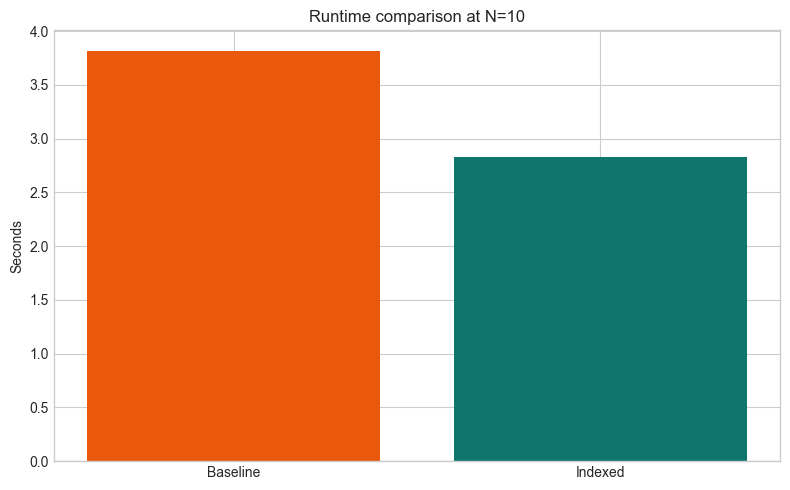

Saved runtime comparison chart to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task03\task03_runtime_compare.png
Best N based on RMSE: 10
Similarity metric note: zeros are treated as missing values because similarity is computed only on co-rated items.


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["Baseline", "Indexed"], [runtime_result["baseline"], runtime_result["indexed"]], color=["#ea580c", "#0f766e"])
ax.set_title(f"Runtime comparison at N={best_n}")
ax.set_ylabel("Seconds")
fig.tight_layout()
fig.savefig(RUNTIME_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
print("Saved runtime comparison chart to", RUNTIME_CHART_PATH)
assert RUNTIME_CHART_PATH.exists()

print("Best N based on RMSE:", best_n)
print("Similarity metric note: zeros are treated as missing values because similarity is computed only on co-rated items.")


## 15. Release Spark Resources


In [15]:
ratings_df.unpersist()
train_df.unpersist()
test_df.unpersist()
spark.stop()
